# Phase 6 — Neural Networks with TensorFlow/Keras

**Goal:** Build a multi-layer dense neural network to classify spectral classes. Learn Keras model construction, regularization techniques, and training callbacks.

**Libraries:** `tensorflow` / `keras`, `pandas`, `scikit-learn`, `matplotlib`

**Input:** `../star_dataset_clean.csv`

**Install if needed:** `pip install tensorflow`

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import tensorflow as tf

os.makedirs("../figures", exist_ok=True)
print("TensorFlow version:", tf.__version__)

In [7]:
df = pd.read_csv("../star_dataset_clean.csv")

feature_cols = ['Distance (ly)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Temperature (K)']
X = df[feature_cols].values
y = df['Spectral Class'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
n_classes = len(label_encoder.classes_)
print(f"Total samples: {len(X)},  Classes: {n_classes}")

# 70 / 15 / 15 split
# Step 1: cut off 15% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y_encoded, test_size=0.15, random_state=42)
# Step 2: from the remaining 85%, cut off ~15% of total as val (15/85 ≈ 0.18)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.18, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape},  Val: {X_val_scaled.shape},  Test: {X_test_scaled.shape}")

Total samples: 29,  Classes: 28
Train: (19, 4),  Val: (5, 4),  Test: (5, 4)


In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(n_classes, activation='softmax'),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 28)             │           924 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,580 (13.98 KB)

 Trainable params: 3,452 (13.48 KB)

 Non-trainable params: 128 (512.00 B)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 242ms/step - accuracy: 0.1053 - loss: 3.7923 - val_accuracy: 0.0000e+00 - val_loss: 3.4401
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.0526 - loss: 3.6830 - val_accuracy: 0.0000e+00 - val_loss: 3.4426
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.0000e+00 - loss: 3.6267 - val_accuracy: 0.0000e+00 - val_loss: 3.4483
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.0526 - loss: 3.4342 - val_accuracy: 0.0000e+00 - val_loss: 3.4520
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.0526 - loss: 3.3109 - val_accuracy: 0.0000e+00 - val_loss: 3.4552
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.0000e+00 - loss: 3.4202 - val_accuracy: 0.0000e+00 - val_loss: 3.4608
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.1053 - loss: 3.0731 - val_accuracy: 0.0000e+00 - val_loss: 3.4690
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.1053 - loss: 3.1

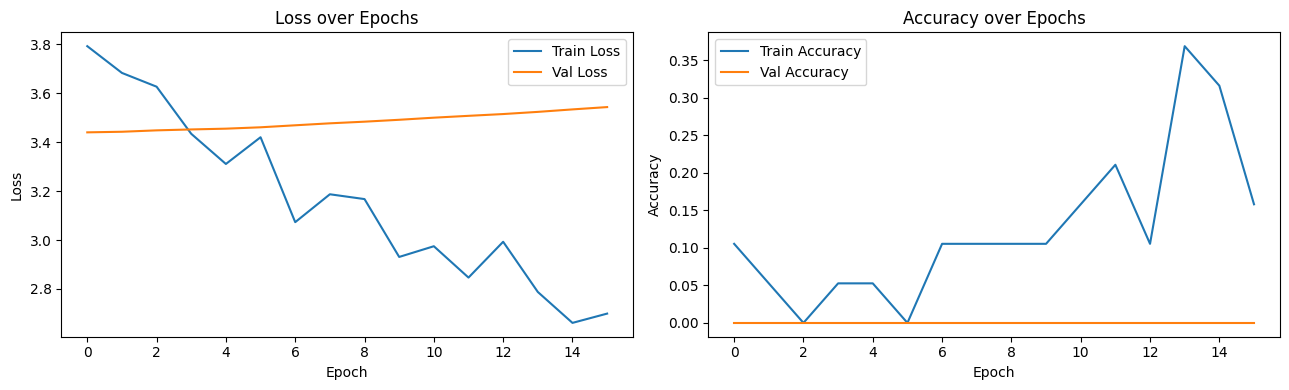

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/phase6_training_curves.png", dpi=150)
plt.show()

In [12]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

y_proba = model.predict(X_test_scaled, verbose=0)
y_pred  = np.argmax(y_proba, axis=1)

# Only report on classes present in this test split (same fix as phases 3 & 4)
present_labels = sorted(set(y_test) | set(y_pred))
present_names  = label_encoder.inverse_transform(present_labels)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=present_labels, target_names=present_names))

Test Loss:     3.4756
Test Accuracy: 0.0000

Classification Report:
              precision    recall  f1-score   support

         A0V       0.00      0.00      0.00       1.0
        A2Ia       0.00      0.00      0.00       0.0
        A9II       0.00      0.00      0.00       0.0
       B1III       0.00      0.00      0.00       1.0
        B8Ia       0.00      0.00      0.00       1.0
       G8III       0.00      0.00      0.00       1.0
       M3.5V       0.00      0.00      0.00       0.0
        M4Ve       0.00      0.00      0.00       1.0

    accuracy                           0.00       5.0
   macro avg       0.00      0.00      0.00       5.0
weighted avg       0.00      0.00      0.00       5.0



c:\Users\ajgeb\Desktop\Tech & Coding\Coding_Project\astronomy_data_analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ajgeb\Desktop\Tech & Coding\Coding_Project\astronomy_data_analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ajgeb\Desktop\Tech & Coding\Coding_Project\astronomy_data_analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples